In [ ]:
#type: ignore
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import joblib
df = pd.read_csv("../data/food_delivery_dataset.csv")
print("import is done")

import is done


In [227]:
print(df.shape)
print("\n")
print(df.dtypes)
print("\n")
print(df.info())
print("\n")
df.head()

(45593, 20)


ID                                 str
Delivery_person_ID                 str
Delivery_person_Age                str
Delivery_person_Ratings            str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Vehicle_condition                int64
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                    str
dtype: object


<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19/03/2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25/03/2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19/03/2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05/04/2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26/03/2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


## drop unwanted columns

In [228]:
df.drop(columns=["ID", "Delivery_person_ID","Vehicle_condition","Delivery_person_Ratings"], inplace=True)
print("columns droped")

columns droped


## turn string data to numbers and remove texte parasite

time taken

In [229]:
print(df["Time_taken(min)"].value_counts(dropna=False))

df["Time_taken(min)"] = df["Time_taken(min)"].str.replace("(min)", "",regex=False).str.strip()
df["Time_taken(min)"] = pd.to_numeric(df["Time_taken(min)"], errors='coerce')
print(df.dtypes)

Time_taken(min)
(min) 26    2123
(min) 25    2050
(min) 27    1976
(min) 28    1965
(min) 29    1956
(min) 19    1824
(min) 15    1810
(min) 18    1765
(min) 16    1706
(min) 17    1696
(min) 24    1680
(min) 23    1643
(min) 20    1640
(min) 22    1626
(min) 21    1601
(min) 33    1259
(min) 30    1218
(min) 31    1213
(min) 34    1172
(min) 32    1124
(min) 38     887
(min) 36     852
(min) 39     847
(min) 35     832
(min) 37     828
(min) 11     757
(min) 10     750
(min) 12     746
(min) 14     739
(min) 13     716
(min) 43     567
(min) 42     561
(min) 40     555
(min) 41     553
(min) 44     553
(min) 47     295
(min) 49     280
(min) 48     277
(min) 46     274
(min) 45     241
(min) 53     100
(min) 51      94
(min) 54      91
(min) 52      79
(min) 50      72
Name: count, dtype: int64
Delivery_person_Age                str
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float6

weather

In [230]:
df["Weatherconditions"] = df["Weatherconditions"].str.replace("conditions ", "",regex=False).str.strip()

clean categorical columns

In [231]:
cat_cols = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_order",
    "Type_of_vehicle",
    "City"
]

for col in cat_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(["NaN", "nan"], np.nan)

person age

In [232]:
print(df["Delivery_person_Age"].value_counts(dropna=False))

df["Delivery_person_Age"] = pd.to_numeric(df["Delivery_person_Age"], errors='coerce')
print(df.dtypes)

Delivery_person_Age
35      2262
36      2260
37      2227
30      2226
38      2219
24      2210
32      2202
22      2196
29      2191
33      2187
28      2179
25      2174
34      2166
26      2159
21      2153
27      2150
39      2144
20      2136
31      2120
23      2087
NaN     1854
50        53
15        38
Name: count, dtype: int64
Delivery_person_Age            float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                         str
Time_Orderd                        str
Time_Order_picked                  str
Weatherconditions                  str
Road_traffic_density               str
Type_of_order                      str
Type_of_vehicle                    str
multiple_deliveries                str
Festival                           str
City                               str
Time_taken(min)                  int64
dtype: object


date

In [233]:
print(df["Order_Date"].value_counts(dropna=False))
df["Order_Date"] = pd.to_datetime(df["Order_Date"], format="%d/%m/%Y", errors='coerce')
print(df.dtypes)

Order_Date
15/03/2022    1192
03/04/2022    1178
13/03/2022    1169
26/03/2022    1166
24/03/2022    1162
09/03/2022    1159
05/04/2022    1157
05/03/2022    1154
07/03/2022    1153
19/03/2022    1150
03/03/2022    1150
11/03/2022    1149
21/03/2022    1149
30/03/2022    1141
01/03/2022    1140
28/03/2022    1139
17/03/2022    1134
01/04/2022    1133
02/03/2022    1012
10/03/2022     996
16/03/2022     995
20/03/2022     994
02/04/2022     992
06/03/2022     986
04/03/2022     981
29/03/2022     977
25/03/2022     975
14/03/2022     974
11/02/2022     970
18/03/2022     968
31/03/2022     967
27/03/2022     965
12/03/2022     964
08/03/2022     964
23/03/2022     964
06/04/2022     961
13/02/2022     957
15/02/2022     945
04/04/2022     941
17/02/2022     939
12/02/2022     864
16/02/2022     861
18/02/2022     855
14/02/2022     851
Name: count, dtype: int64
Delivery_person_Age                   float64
Restaurant_latitude                   float64
Restaurant_longitude               

time ordered

In [234]:
print(df["Time_Orderd"].value_counts(dropna=False))
df["Time_Orderd"] = pd.to_timedelta(df["Time_Orderd"], errors='coerce')
print(df.dtypes)

Time_Orderd
NaN         1731
21:55:00     461
17:55:00     456
20:00:00     449
22:20:00     448
            ... 
14:30:00      57
14:15:00      56
16:00:00      53
13:20:00      52
16:30:00      51
Name: count, Length: 177, dtype: int64
Delivery_person_Age                    float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked                          str
Weatherconditions                          str
Road_traffic_density                       str
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                        str
Festival                                   str
City                                       str
Time_taken(min)                          int64
dtype: obj

time order picked

In [235]:
print(df["Time_Order_picked"].value_counts(dropna=False))
df["Time_Order_picked"] = pd.to_timedelta(df["Time_Order_picked"], errors='coerce')
print(df.dtypes)

Time_Order_picked
21:30:00    496
22:50:00    474
22:40:00    458
18:40:00    457
21:45:00    456
           ... 
14:20:00     48
16:15:00     46
16:10:00     43
17:10:00     39
16:20:00     38
Name: count, Length: 193, dtype: int64
Delivery_person_Age                    float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked              timedelta64[us]
Weatherconditions                          str
Road_traffic_density                       str
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                        str
Festival                                   str
City                                       str
Time_taken(min)                          int64
dtype: object


multi deliveries

In [236]:
print(df["multiple_deliveries"].value_counts(dropna=False))
df["multiple_deliveries"] = pd.to_numeric(df["multiple_deliveries"], errors='coerce')
print(df.dtypes)

multiple_deliveries
1       28159
0       14095
2        1985
NaN       993
3         361
Name: count, dtype: int64
Delivery_person_Age                    float64
Restaurant_latitude                    float64
Restaurant_longitude                   float64
Delivery_location_latitude             float64
Delivery_location_longitude            float64
Order_Date                      datetime64[us]
Time_Orderd                    timedelta64[us]
Time_Order_picked              timedelta64[us]
Weatherconditions                          str
Road_traffic_density                       str
Type_of_order                              str
Type_of_vehicle                            str
multiple_deliveries                    float64
Festival                                   str
City                                       str
Time_taken(min)                          int64
dtype: object


In [237]:
df.head()

,Delivery_person_Age,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,37.0,22.745049,75.892471,22.765049,75.912471,2022-03-19,0 days 11:30:00,0 days 11:45:00,Sunny,High,Snack,motorcycle,0.0,No,Urban,24
1,34.0,12.913041,77.683237,13.043041,77.813237,2022-03-25,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,Snack,scooter,1.0,No,Metropolitian,33
2,23.0,12.914264,77.678400,12.924264,77.688400,2022-03-19,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,Drinks,motorcycle,1.0,No,Urban,26
3,38.0,11.003669,76.976494,11.053669,77.026494,2022-04-05,0 days 18:00:00,0 days 18:10:00,Sunny,Medium,Buffet,motorcycle,1.0,No,Metropolitian,21
4,32.0,12.972793,80.249982,13.012793,80.289982,2022-03-26,0 days 13:30:00,0 days 13:45:00,Cloudy,High,Snack,scooter,1.0,No,Metropolitian,30


## detection of mssing values

In [238]:
coord_cols = [
    "Restaurant_latitude", 
    "Restaurant_longitude", 
    "Delivery_location_latitude", 
    "Delivery_location_longitude"
]
df[coord_cols]=df[coord_cols].abs()
invalid_coords_mask = (df[coord_cols].abs() < 1.0).any(axis=1)
df = df[~invalid_coords_mask]
print("New dataset shape:", df.shape)

New dataset shape: (41953, 16)


In [239]:
for col in cat_cols:
    print(f"--- Unique values in {col} ---")
    print(df[col].unique())
    print()

--- Unique values in Weatherconditions ---
<ArrowStringArray>
['Sunny', 'Stormy', 'Sandstorms', 'Cloudy', 'Fog', 'Windy', nan]
Length: 7, dtype: str

--- Unique values in Road_traffic_density ---
<ArrowStringArray>
['High', 'Jam', 'Low', 'Medium', nan]
Length: 5, dtype: str

--- Unique values in Type_of_order ---
<ArrowStringArray>
['Snack', 'Drinks', 'Buffet', 'Meal']
Length: 4, dtype: str

--- Unique values in Type_of_vehicle ---
<ArrowStringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str

--- Unique values in City ---
<ArrowStringArray>
['Urban', 'Metropolitian', nan, 'Semi-Urban']
Length: 4, dtype: str



In [240]:
df.isna().sum()

Delivery_person_Age            1719
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions               569
Road_traffic_density            555
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                           1114
Time_taken(min)                   0
dtype: int64

## handling missing values

person age

In [241]:
df["Delivery_person_Age"].describe()

count    40234.000000
mean        29.563330
std          5.812361
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [242]:
df["Delivery_person_Age"]=df["Delivery_person_Age"].fillna(df["Delivery_person_Age"].median())

waether conditions

In [243]:
df["Weatherconditions"] = df["Weatherconditions"].fillna(
    df["Weatherconditions"].mode()[0]
)

cities

In [244]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

traffic density

In [245]:
df["Road_traffic_density"]= df["Road_traffic_density"].fillna(df["Road_traffic_density"].mode()[0])

time ordered

In [246]:
df = df.dropna(subset=["Time_Orderd"])

multi deliveries

In [247]:
df["multiple_deliveries"].describe()

count    39498.00000
mean         0.74462
std          0.57227
min          0.00000
25%          0.00000
50%          1.00000
75%          1.00000
max          3.00000
Name: multiple_deliveries, dtype: float64

In [248]:
df["multiple_deliveries"] = df["multiple_deliveries"].fillna(df["multiple_deliveries"].median())

drop duplicated

In [249]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print("New dataset shape after dropping duplicates:", df.shape)

Number of duplicate rows: 0


checking

In [250]:
print(df.shape)
print()
print(df.isna().sum())

(40353, 16)

Delivery_person_Age            0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


# EDA

In [251]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Delivery_person_Age,40353.0,29.554829,20.0,25.0,30.0,35.0,39.0,5.746713
Restaurant_latitude,40353.0,18.911836,9.957144,12.986047,19.065838,22.751234,30.914057,5.468296
Restaurant_longitude,40353.0,76.91848,72.768726,73.897902,76.618203,78.368855,88.433452,3.500531
Delivery_location_latitude,40353.0,18.975471,9.967144,13.065996,19.124049,22.82004,31.054057,5.470105
Delivery_location_longitude,40353.0,76.982116,72.778726,73.940327,76.662278,78.403391,88.563452,3.500743
Order_Date,40353,2022-03-14 04:52:45.623373,2022-02-11 00:00:00,2022-03-05 00:00:00,2022-03-15 00:00:00,2022-03-27 00:00:00,2022-04-06 00:00:00,NaN
Time_Orderd,40353,0 days 17:54:52.431789,0 days 00:00:00,0 days 15:25:00,0 days 19:15:00,0 days 21:35:00,0 days 23:55:00,0 days 04:50:17.422557
Time_Order_picked,40353,0 days 17:37:39.631254,0 days 00:00:00,0 days 14:35:00,0 days 19:10:00,0 days 21:35:00,0 days 23:55:00,0 days 05:21:15.788260
multiple_deliveries,40353.0,0.750031,0.0,0.0,1.0,1.0,3.0,0.567368
Time_taken(min),40353.0,26.312641,10.0,19.0,26.0,32.0,54.0,9.371416


In [252]:

for col in cat_cols:
    print(df[col].value_counts())
    print()

Weatherconditions
Fog           6845
Stormy        6806
Cloudy        6747
Sandstorms    6717
Windy         6675
Sunny         6563
Name: count, dtype: int64

Road_traffic_density
Low       13816
Jam       12726
Medium     9836
High       3975
Name: count, dtype: int64

Type_of_order
Snack     10196
Meal      10119
Drinks    10059
Buffet     9979
Name: count, dtype: int64

Type_of_vehicle
motorcycle          23660
scooter             13489
electric_scooter     3204
Name: count, dtype: int64

City
Metropolitian    31279
Urban             8933
Semi-Urban         141
Name: count, dtype: int64



### distribution of time taken

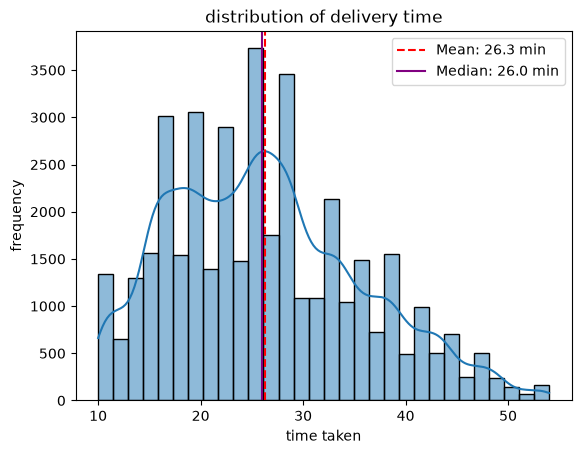

In [253]:
sns.histplot(df["Time_taken(min)"], kde=True, bins=30)

plt.axvline(
    df["Time_taken(min)"].mean(),
    color="red",
    linestyle="--",
    label=f"Mean: {df['Time_taken(min)'].mean():.1f} min",
)
plt.axvline(
    df["Time_taken(min)"].median(),
    color="purple",
    linestyle="-",
    label=f"Median: {df['Time_taken(min)'].median():.1f} min",
)

plt.title("distribution of delivery time")
plt.xlabel("time taken")
plt.ylabel("frequency")
plt.legend()
plt.show()

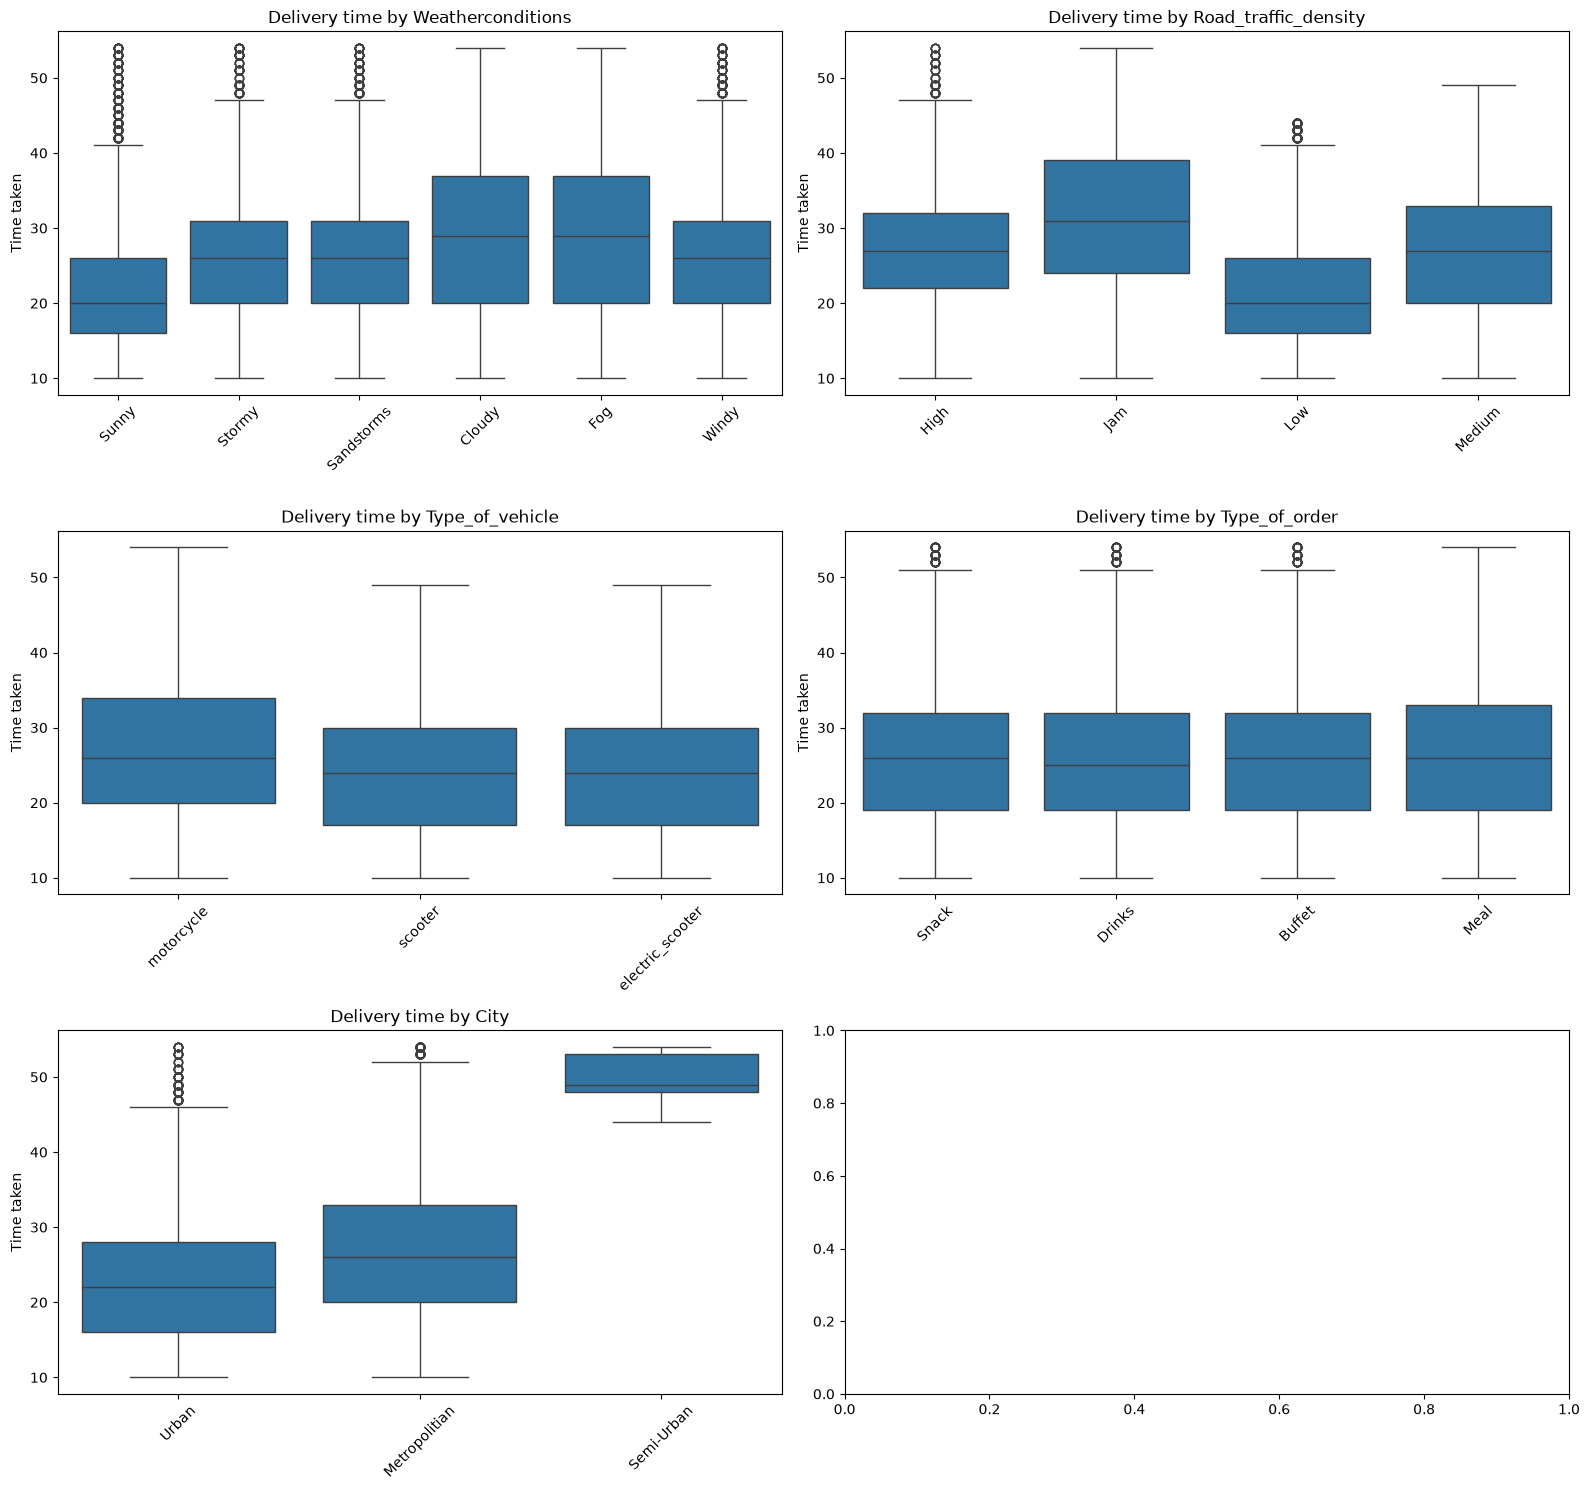

In [254]:
categorical_to_plot = [
    "Weatherconditions",
    "Road_traffic_density",
    "Type_of_vehicle",
    "Type_of_order",
    "City",
]

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for idx, col in enumerate(categorical_to_plot):
    sns.boxplot(
        data=df,
        x=col,
        y="Time_taken(min)",
        ax=axes[idx]
    )
    axes[idx].set_title(f"Delivery time by {col}")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("Time taken")
    axes[idx].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()

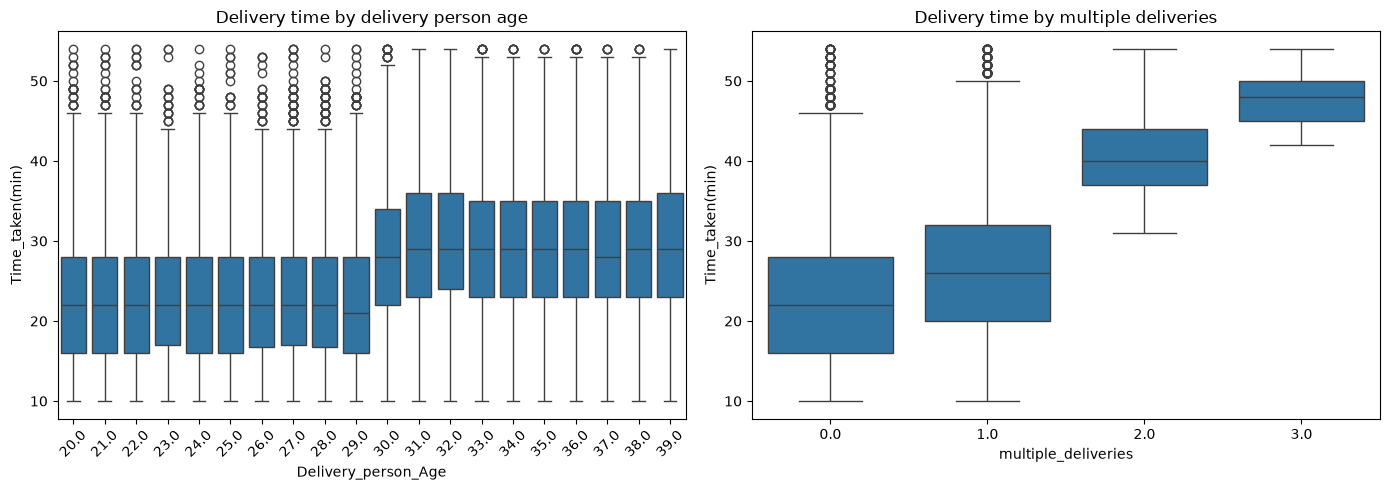

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Delivery_person_Age",
    y="Time_taken(min)",
    ax=axes[0],
)
axes[0].set_title("Delivery time by delivery person age")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=df,
    x="multiple_deliveries",
    y="Time_taken(min)",
    ax=axes[1],
)
axes[1].set_title("Delivery time by multiple deliveries")

plt.tight_layout()
plt.show()

In [256]:
R= 6371
lat1=np.radians(df["Delivery_location_latitude"])
lng1=np.radians(df["Delivery_location_longitude"])
lat2=np.radians(df["Restaurant_latitude"])
lng2=np.radians(df["Restaurant_longitude"])
dlat=lat2-lat1
dlng=lng2-lng1
a = np.sin(dlat/2)**2+np.cos(lat1)*np.cos(lat2)*np.sin(dlng/2)**2
df["distance_km"]=2 * R * np.arcsin(np.sqrt(a))

In [257]:
df["prep_time_min"] = (
    df["Time_Order_picked"] - df["Time_Orderd"]
).dt.total_seconds() / 60.0

df["prep_time_min"] = df["prep_time_min"].apply(
    lambda x: x + 1440 if x < 0 else x
)

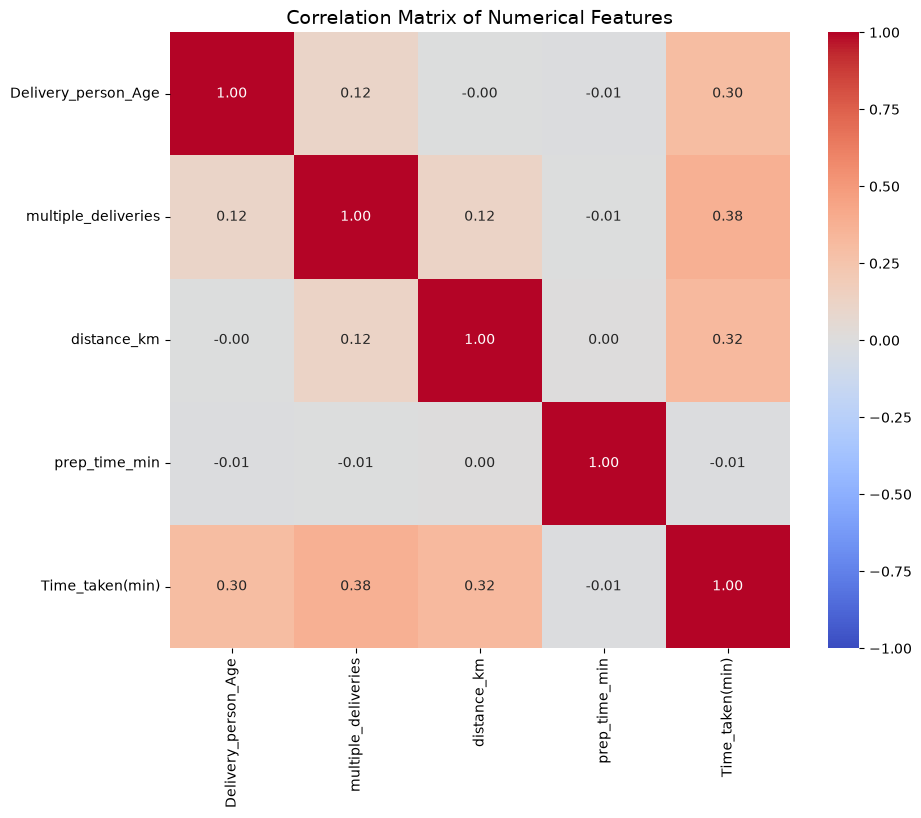

In [258]:
numeric_subset = df[
    [
        "Delivery_person_Age",
        "multiple_deliveries",
        "distance_km",
        "prep_time_min",
        "Time_taken(min)",
    ]
]

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_subset.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix of Numerical Features", fontsize=14)
plt.show()


In [259]:
df.drop(columns=["Delivery_location_latitude", "Delivery_location_longitude","Restaurant_latitude","Restaurant_longitude","Time_Order_picked","Time_Orderd"])

,Delivery_person_Age,Order_Date,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,prep_time_min
0,37.0,2022-03-19,Sunny,High,Snack,motorcycle,0.0,No,Urban,24,3.025149,15.0
1,34.0,2022-03-25,Stormy,Jam,Snack,scooter,1.0,No,Metropolitian,33,20.183530,5.0
2,23.0,2022-03-19,Sandstorms,Low,Drinks,motorcycle,1.0,No,Urban,26,1.552758,15.0
3,38.0,2022-04-05,Sunny,Medium,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,10.0
4,32.0,2022-03-26,Cloudy,High,Snack,scooter,1.0,No,Metropolitian,30,6.210138,15.0
...,...,...,...,...,...,...,...,...,...,...,...,...
45587,35.0,2022-03-08,Windy,Jam,Drinks,motorcycle,1.0,No,Metropolitian,33,16.600272,10.0
45588,30.0,2022-03-24,Windy,High,Meal,motorcycle,0.0,No,Metropolitian,32,1.489846,10.0
45590,30.0,2022-03-11,Cloudy,Low,Drinks,scooter,0.0,No,Metropolitian,16,4.657195,15.0
45591,20.0,2022-03-07,Cloudy,High,Snack,motorcycle,1.0,No,Metropolitian,26,6.232393,5.0


In [260]:
df.head()

,Delivery_person_Age,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min),distance_km,prep_time_min
0,37.0,22.745049,75.892471,22.765049,75.912471,2022-03-19,0 days 11:30:00,0 days 11:45:00,Sunny,High,Snack,motorcycle,0.0,No,Urban,24,3.025149,15.0
1,34.0,12.913041,77.683237,13.043041,77.813237,2022-03-25,0 days 19:45:00,0 days 19:50:00,Stormy,Jam,Snack,scooter,1.0,No,Metropolitian,33,20.183530,5.0
2,23.0,12.914264,77.678400,12.924264,77.688400,2022-03-19,0 days 08:30:00,0 days 08:45:00,Sandstorms,Low,Drinks,motorcycle,1.0,No,Urban,26,1.552758,15.0
3,38.0,11.003669,76.976494,11.053669,77.026494,2022-04-05,0 days 18:00:00,0 days 18:10:00,Sunny,Medium,Buffet,motorcycle,1.0,No,Metropolitian,21,7.790401,10.0
4,32.0,12.972793,80.249982,13.012793,80.289982,2022-03-26,0 days 13:30:00,0 days 13:45:00,Cloudy,High,Snack,scooter,1.0,No,Metropolitian,30,6.210138,15.0



# Numerical: mean because the distribution has no significant outliers

In [261]:
for column in ["Delivery_person_Age", "prep_time_min", "Time_taken(min)"]:
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(column, ":", len(outliers), "outliers")

print()
print(df["Time_taken(min)"].max())

Delivery_person_Age : 0 outliers
prep_time_min : 0 outliers
Time_taken(min) : 232 outliers

54


In [262]:

num_features = [
    "Delivery_person_Age",
    "multiple_deliveries",
    "distance_km",
    "prep_time_min",
]

ordinal_features = ["Road_traffic_density"]


traffic_order = [["Low", "Medium", "High", "Jam"]]

nominal_features = [
    "Weatherconditions",
    "Type_of_vehicle",
    "City",
    "Festival",
]

all_features = (
    num_features
    + ordinal_features
    + [col for col in nominal_features if col in df.columns]
)

X = df[all_features]
y = df["Time_taken(min)"]

#split the raw data first (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# define the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        (
            "ord",
            OrdinalEncoder(
                categories=traffic_order,
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
            ordinal_features,
        ),
        (
            "nom",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            [col for col in nominal_features if col in df.columns],
        ),
    ]
)

In [263]:
# 1. Choose the 4 candidate models
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150, learning_rate=0.1, max_depth=5, random_state=42
    ),
}

# 2. Train and evaluate each model in a loop
results = []

for name, model in models.items():
    print(f"Training {name}...")

    # Combine preprocessor + model into a single pipeline
    pipe = Pipeline(
        steps=[("preprocessor", preprocessor), ("regressor", model)]
    )

    # Train strictly on the training set
    pipe.fit(X_train, y_train)

    # Make predictions on test set
    y_pred = pipe.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({"Model": name, "MAE (min)": mae, "RMSE (min)": rmse, "R²": r2})

# 3. Print the comparison table
results_df = pd.DataFrame(results).sort_values(by="MAE (min)")
print("\n--- MODEL BENCHMARK RESULTS ---")
print(results_df.to_string(index=False))

Training Linear Regression...


Training Ridge Regression...
Training Random Forest...
Training Gradient Boosting...

--- MODEL BENCHMARK RESULTS ---
            Model  MAE (min)  RMSE (min)       R²
    Random Forest   3.824760    4.838263 0.733942
Gradient Boosting   3.828489    4.852055 0.732423
 Ridge Regression   5.191713    6.533812 0.514788
Linear Regression   5.191737    6.533830 0.514786


In [ ]:


# 1. Define the base pipeline with Random Forest
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1)),
    ]
)

# 2. Define the hyperparameter search space
param_distributions = {
    "regressor__n_estimators": [100, 150, 200],
    "regressor__max_depth": [10, 15, 20, None],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
}

# 3. Run randomized search cross-validation
random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=8,  # tests 8 random combinations
    cv=3,  # 3-fold cross validation
    scoring="neg_mean_absolute_error",
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

print("Starting hyperparameter tuning...")
random_search.fit(X_train, y_train)

# 4. Extract best pipeline
best_pipeline = random_search.best_estimator_
print("\nBest Parameters Found:")
print(random_search.best_params_)

# 5. Overfitting check (Train vs Test)
train_preds = best_pipeline.predict(X_train)
test_preds = best_pipeline.predict(X_test)

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)
test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print("\n--- FINAL EVALUATION ---")
print(f"Train MAE: {train_mae:.2f} min")
print(f"Test MAE:  {test_mae:.2f} min")
print(f"Test RMSE: {test_rmse:.2f} min")
print(f"Test R²:   {test_r2:.3f}")

# 6. Save the fitted pipeline artifact for Streamlit
joblib.dump(best_pipeline, "best_delivery_pipeline.pkl")
print("\nModel pipeline saved successfully as 'best_delivery_pipeline.pkl'!")

Starting hyperparameter tuning...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters Found:
{'regressor__n_estimators': 100, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 4, 'regressor__max_depth': 15}

--- FINAL EVALUATION ---
Train MAE: 3.09 min
Test MAE:  3.86 min
Test RMSE: 4.92 min
Test R²:   0.725

Model pipeline saved successfully as 'best_delivery_pipeline.pkl'!


In [264]:
# outliers = df[
#     (df["Delivery_Time_min"] < lower) |
#     (df["Delivery_Time_min"] > upper)
# ]

# print(outliers)

## deleting the 3 unusual outliers not because they are just outliers but because the big amount of time token in good condition using car compare to some low amount of time token by bikes/scooter in bad conditions

In [265]:
plt.hist( df["Delivery_Time_min"])

plt.ylabel("number of deliveries")
plt.xlabel("Delivery Time (min)")
plt.title("Delivery Time ")

plt.show()

KeyError: 'Delivery_Time_min'

In [ ]:
plt.scatter(df["Distance_km"], df["Delivery_Time_min"])

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Time (min)")
plt.title("Distance vs Delivery Time")

plt.show()